# Student Performance Analyzer

In [40]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Pandas: 3.0.6
NumPy: 2.5.3
Matplotlib: 3.11.2


## 1. Load the Dataset

In [21]:

df = pd.read_csv("data/students.csv")

df

,Student_ID,Name,Python,Database,Statistics,Attendance
0,101,Ali,78,82,75,90
1,102,Sara,92,88,95,96
2,103,Ahmed,65,70,68,82
3,104,Ayesha,85,91,89,94
4,105,Hamza,55,62,58,75
5,106,Fatima,88,84,90,92
6,107,Usman,72,76,70,85
7,108,Zainab,96,93,97,98
8,109,Hassan,61,67,64,78
9,110,Maria,81,79,86,91


## 2. Initial Data Exploration

In [22]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape: (10, 6)

Columns:
['Student_ID', 'Name', 'Python', 'Database', 'Statistics', 'Attendance']

Data types:
Student_ID    int64
Name            str
Python        int64
Database      int64
Statistics    int64
Attendance    int64
dtype: object


In [23]:
df.describe()

,Student_ID,Python,Database,Statistics,Attendance
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,105.50000,77.300000,79.200000,79.200000,88.100000
std,3.02765,13.727912,10.422199,13.878841,7.766738
min,101.00000,55.000000,62.000000,58.000000,75.000000
25%,103.25000,66.750000,71.500000,68.500000,82.750000
50%,105.50000,79.500000,80.500000,80.500000,90.500000
75%,107.75000,87.250000,87.000000,89.750000,93.500000
max,110.00000,96.000000,93.000000,97.000000,98.000000


In [24]:
df.isnull().sum()

Student_ID    0
Name          0
Python        0
Database      0
Statistics    0
Attendance    0
dtype: int64

In [25]:
df["Average"]= df[["Python", "Database", "Statistics"]].mean(axis=1)

In [26]:
df

,Student_ID,Name,Python,Database,Statistics,Attendance,Average
0,101,Ali,78,82,75,90,78.333333
1,102,Sara,92,88,95,96,91.666667
2,103,Ahmed,65,70,68,82,67.666667
3,104,Ayesha,85,91,89,94,88.333333
4,105,Hamza,55,62,58,75,58.333333
5,106,Fatima,88,84,90,92,87.333333
6,107,Usman,72,76,70,85,72.666667
7,108,Zainab,96,93,97,98,95.333333
8,109,Hassan,61,67,64,78,64.000000
9,110,Maria,81,79,86,91,82.000000


In [27]:
def classify_performance(average):
    if average >= 80:
        return "Excellent"
    elif average >= 70:
        return "Good"
    elif average >= 60:
        return "Satisfactory"
    else:
        return "Needs Improvement"

df["Performance"] = df["Average"].apply(classify_performance)
df

,Student_ID,Name,Python,Database,Statistics,Attendance,Average,Performance
0,101,Ali,78,82,75,90,78.333333,Good
1,102,Sara,92,88,95,96,91.666667,Excellent
2,103,Ahmed,65,70,68,82,67.666667,Satisfactory
3,104,Ayesha,85,91,89,94,88.333333,Excellent
4,105,Hamza,55,62,58,75,58.333333,Needs Improvement
5,106,Fatima,88,84,90,92,87.333333,Excellent
6,107,Usman,72,76,70,85,72.666667,Good
7,108,Zainab,96,93,97,98,95.333333,Excellent
8,109,Hassan,61,67,64,78,64.000000,Satisfactory
9,110,Maria,81,79,86,91,82.000000,Excellent


## 3. Performance Analysis

In [28]:
class_average = df["Average"].mean()
print("Class Average:", class_average)

Class Average: 78.56666666666666


In [29]:
top_student = df.loc[df["Average"].idxmax()]
print(top_student)

Student_ID           108
Name              Zainab
Python                96
Database              93
Statistics            97
Attendance            98
Average        95.333333
Performance    Excellent
Name: 7, dtype: object


In [30]:
lowest_student = df.loc[df["Average"].idxmin()]
print(lowest_student)

Student_ID                   105
Name                       Hamza
Python                        55
Database                      62
Statistics                    58
Attendance                    75
Average                58.333333
Performance    Needs Improvement
Name: 4, dtype: object


In [31]:
subject_average = df[["Python" , "Database", "Statistics"]].mean()
print(subject_average)

Python        77.3
Database      79.2
Statistics    79.2
dtype: float64


In [32]:
performance_counts = df["Performance"].value_counts()
print(performance_counts)

Performance
Excellent            5
Good                 2
Satisfactory         2
Needs Improvement    1
Name: count, dtype: int64


In [33]:
attendance_performance = df[["Attendance", "Average"]]

print(attendance_performance)

   Attendance    Average
0          90  78.333333
1          96  91.666667
2          82  67.666667
3          94  88.333333
4          75  58.333333
5          92  87.333333
6          85  72.666667
7          98  95.333333
8          78  64.000000
9          91  82.000000


In [34]:
correlation = df["Attendance"].corr(df["Average"])
print("Attendance Average correlation:", correlation)

Attendance Average correlation: 0.9911148556016561


In [35]:
print("Class Average:", class_average)

print("\nTop-performing student:")
print(top_student)

print("\nLowest-performing student:")
print(lowest_student)

print("\nSubject Averages:")
print(subject_average)

print("\nPerformance Categories:")
print(performance_counts)

print("\nAttendance-Average Correlation:", correlation)

Class Average: 78.56666666666666

Top-performing student:
Student_ID           108
Name              Zainab
Python                96
Database              93
Statistics            97
Attendance            98
Average        95.333333
Performance    Excellent
Name: 7, dtype: object

Lowest-performing student:
Student_ID                   105
Name                       Hamza
Python                        55
Database                      62
Statistics                    58
Attendance                    75
Average                58.333333
Performance    Needs Improvement
Name: 4, dtype: object

Subject Averages:
Python        77.3
Database      79.2
Statistics    79.2
dtype: float64

Performance Categories:
Performance
Excellent            5
Good                 2
Satisfactory         2
Needs Improvement    1
Name: count, dtype: int64

Attendance-Average Correlation: 0.9911148556016561


## 4. Visualizations

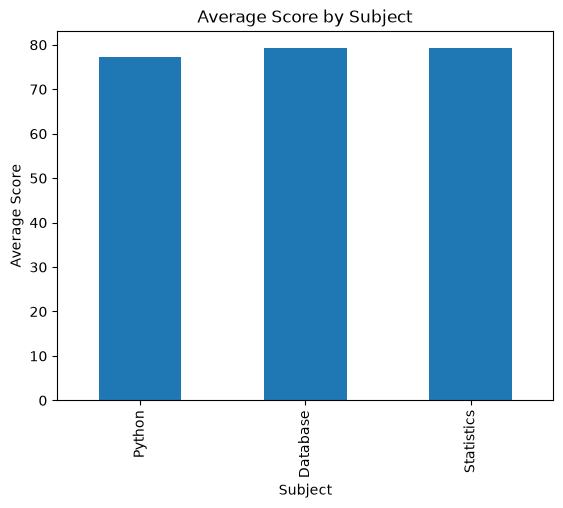

In [41]:
subject_average.plot(kind="bar")

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.show()